# This is an example of Gradient Boosting technique I did as a part of a Machine Learning course during my master degree.

# Машинное обучение, РЭШ, Вариошкин Никита

## Практическое задание 5. Градиентный бустинг ~~своими руками~~

### Общая информация
Дата выдачи: 06.12.2020

Мягкий дедлайн: 23:59MSK 13.12.2020

Жесткий дедлайн: 23:59MSK 15.12.2020

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). 

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Задания сдаются на my.nes. 


__Задание 1. (0.5 балла)__

Мы будем использовать данные из [соревнования](https://www.kaggle.com/t/b710e05dc0bd424995ca94da5b639869). 
* Загрузите таблицу application_train.csv;
* Запишите в Y столбец с целевой переменной (TARGET);
* Удалите ненужные столбцы (для этого воспользуйтесь описанием);
* Определите тип столбцов и заполните пропуски - стратегия произвольная;
* Разбейте выборку в соотношении 70:30 с random_state=0.

Так как в данных имеется значительный дисбаланс классов, в качестве метрики качества везде будем использовать площадь под precision-recall кривой (AUC-PR).

In [295]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [296]:
pd.options.display.max_rows = 130

In [297]:
d = pd.read_csv('application_train.csv')
Y = d['TARGET']
d.drop('TARGET', axis = 1, inplace = True)

Давайте посмотрим на количество пропусков в каждой колонке:

In [298]:
d.isna().sum().sort_values(ascending = False)

COMMONAREA_MEDI                 150377
COMMONAREA_AVG                  150377
COMMONAREA_MODE                 150377
NONLIVINGAPARTMENTS_MODE        149407
NONLIVINGAPARTMENTS_MEDI        149407
NONLIVINGAPARTMENTS_AVG         149407
FONDKAPREMONT_MODE              147183
LIVINGAPARTMENTS_MEDI           147079
LIVINGAPARTMENTS_MODE           147079
LIVINGAPARTMENTS_AVG            147079
FLOORSMIN_AVG                   145996
FLOORSMIN_MEDI                  145996
FLOORSMIN_MODE                  145996
YEARS_BUILD_MEDI                143139
YEARS_BUILD_MODE                143139
YEARS_BUILD_AVG                 143139
OWN_CAR_AGE                     141836
LANDAREA_AVG                    127807
LANDAREA_MEDI                   127807
LANDAREA_MODE                   127807
BASEMENTAREA_AVG                125984
BASEMENTAREA_MODE               125984
BASEMENTAREA_MEDI               125984
EXT_SOURCE_1                    121249
NONLIVINGAREA_MEDI              118888
NONLIVINGAREA_AVG        

У нас есть целый набор числовых признаков с большим количеством пропусков. Это разнообразные характеристики жилого дома, в котором живет заемщик (средняя площадь квартир, высотность и т.д.) Мне бы хотелось использовать максимально возможное число наблюдений, поэтому от этих столбцев мы избавимся. К тому же, они наверняка скореллированы с такими признаками как доход и прочее.


Я не хочу использовать переменные `EXT_SOURCE_1`, `EXT_SOURCE_3`, `OWN_CAR_AGE`, `OCCUPATION_TYPE` и `AMT..` также по причине большого количество пропусков. Переменная `SK_ID_CURR` это id займа в данных и она нам тоже не нужна.

In [299]:
von = []
for i in d.columns:
        if 'MEDI' in i or 'MODE' in i or 'AVG' in i:
            von.append(i)  
            
von.extend(['SK_ID_CURR', 'EXT_SOURCE_1', 'EXT_SOURCE_3', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'AMT_REQ_CREDIT_BUREAU_QRT', 
           'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_DAY', 
            'AMT_REQ_CREDIT_BUREAU_HOUR'
           ])

d.drop(von, axis = 1, inplace = True)

Пропуски в колонке `NAME_TYPE_SUITE` заполним пустым значением. Во всех остальных колонках вставим среднее вместо пропусков. 

In [300]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [301]:
num = d.select_dtypes(['int64', 'float64']).columns
cat = d.select_dtypes('object').columns

impute = SimpleImputer(missing_values = np.nan, strategy = 'mean')

d[num] = impute.fit_transform(d[num])
d[cat] = d[cat].fillna('')

In [302]:
X_train, X_test, y_train, y_test = train_test_split(d, Y, test_size = 0.3, random_state = 0)

X_train = X_train.reset_index().drop('index', axis = 1)
X_test = X_test.reset_index().drop('index', axis = 1)
y_train = y_train.reset_index().drop('index', axis = 1)
y_test = y_test.reset_index().drop('index', axis = 1)

__Задание 2. (1.5 балла)__

Обучите реализации градиентного бустинга LightGBM и Catboost на вещественных признаках без подбора параметров. 
Почему получилась заметная разница в качестве? 

В этом и последующих экспериментах необходимо измерять время обучения моделей.

In [303]:
from sklearn.metrics import average_precision_score as pr
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [304]:
%%time
light = LGBMClassifier()
model_1 = light.fit(X_train[num], y_train)

prob_1 = model_1.predict_proba(X_test[num])[:, 1]

print(f'PR LightGBM : {pr(y_test, prob_1)}')

PR LightGBM : 0.19291312532361865
Wall time: 1.49 s


In [305]:
%%time
catb = CatBoostClassifier(verbose = False)
model_2 = catb.fit(X_train[num], y_train)

prob_2 = model_2.predict_proba(X_test[num])[:, 1]

print(f'PR CatBoost : {pr(y_test, prob_2)}')

PR CatBoost : 0.1946134944386288
Wall time: 29.6 s


Я не вижу большой разницы в качестве, только разницу во времени. Она скорее всего обусловлена разницей в механизме построения деревьев в обоих алгоритмах. 

__Задание 3. (3 балла)__

Подберите оптимальные с точки зрения метрики качества параметры алгоритмов, изменяя:

* глубину деревьев;
* количество деревьев;
* темп обучения.

Масштаб значений предлагается посмотреть в семинаре про библиотеки.

Проанализируйте соотношения глубины и количества деревьев в зависимости от алгоритма. 

In [306]:
from sklearn.model_selection import GridSearchCV

In [307]:
param_dist = {"max_depth": [2, 4, 6, 8],
              "n_estimators": [50, 100, 250, 500],
              "learning_rate": [0.1, 0.05, 0.01],}

In [308]:
%%time
light = LGBMClassifier()

grid = GridSearchCV(light, param_grid = param_dist, cv = 5, n_jobs=-1, scoring = 'average_precision' )
grid.fit(X_train[num], y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Wall time: 3min 19s


In [140]:
%%time
catb = CatBoostClassifier(verbose = False)

grid = GridSearchCV(catb, param_grid = param_dist, cv = 5, n_jobs=-1, scoring = 'average_precision' )
grid.fit(X_train[num], y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
Wall time: 21min 39s


Алгортим майкрософт выбрал менее глубокое дерево по сравнению с алгоритмом яндекса. Количество деревьев оба алгоритма выдали одинаковое. 

__Задание 4. (2 балла)__

Добавьте категориальные признаки к вещественным. Обработку категориальных признаков проводите с помощью One-Hot-Encoding. Как поменялось качество моделей? 


In [313]:
from sklearn.preprocessing import OneHotEncoder

In [314]:
ohe = OneHotEncoder(handle_unknown = 'ignore', sparse = False)

dummy_train = pd.DataFrame(ohe.fit_transform(X_train[cat]))
dummy_test = pd.DataFrame(ohe.transform(X_test[cat]))

X_train_all = pd.concat([X_train[num], dummy_train], axis = 1)
X_test_all = pd.concat([X_test[num], dummy_test], axis = 1)

In [327]:
%%time
light = LGBMClassifier()

grid = GridSearchCV(light, param_grid = param_dist, cv = 5, n_jobs=-1, scoring = 'average_precision' )
grid.fit(X_train_all, y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Wall time: 4min 33s


In [328]:
%%time
catb = CatBoostClassifier(verbose = False)

grid = GridSearchCV(catb, param_grid = param_dist, cv = 5, n_jobs=-1, scoring = 'average_precision' )
grid.fit(X_train_all, y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
Wall time: 23min 39s


In [315]:
%%time
light = LGBMClassifier(learning_rate = 0.1, max_depth = 2, n_estimators = 500)

model_1 = light.fit(X_train_all, y_train)

prob_1 = model_1.predict_proba(X_test_all)[:, 1]

print(f'PR LightGBM : {pr(y_test, prob_1)}')

PR LightGBM : 0.20793472962260912
Wall time: 3.78 s


In [316]:
%%time
catb = CatBoostClassifier(learning_rate = 0.05, max_depth = 6, n_estimators = 500, verbose = False)

model_2 = catb.fit(X_train_all, y_train)

prob_2 = model_2.predict_proba(X_test_all)[:, 1]

print(f'PR CatBoost : {pr(y_test, prob_2)}')

PR CatBoost : 0.20837628694505525
Wall time: 16.6 s


Качетсво улучшилось на 0.1! Два месяца назад я бы сказал, что это фигня какая-то, а не улучшение. Но сейчас то я понимаю! 

__Задание 5. (1.5 балл)__

Реализуйте блендинг подобранных в предыдущем задании моделей и сравните качество. Обратите внимание на данные, на которых обучаются 

In [317]:
from sklearn.base import BaseEstimator, ClassifierMixin

In [318]:
class Bleeding(BaseEstimator, ClassifierMixin) : 
    def __init__(self, one, two, omega = 0.5) : 
        self.one = one
        self.two = two
        self.omega = omega
        
    def fit(self, X_train, y_train) :
        self.one.fit(X_train, y_train)
        self.two.fit(X_train, y_train)
        return self
    
    def predict_proba(self, X_test):
        prob = self.omega * self.one.predict_proba(X_test) + (1 - self.omega) * self.two.predict_proba(X_test)
        return prob

In [319]:
%%time
bled = Bleeding(one = LGBMClassifier(learning_rate = 0.1, max_depth = 2, n_estimators = 500), 
                two = CatBoostClassifier(learning_rate = 0.05, max_depth = 6, n_estimators = 500, verbose = False))


model_3 = bled.fit(X_train_all, y_train)

prob_3 = model_3.predict_proba(X_test_all)[:, 1]

print(f'PR Blending : {pr(y_test, prob_3)}')

PR Blending : 0.20947856975596024
Wall time: 19.8 s


Качество выросло примерно на 0.01

__Задание 6. (1.5 балла)__

В задании 3 вы подобрали гиперпараметры для LightGBM и CatBoost на вещественных признаках. Визуализируйте важности признаков, посчитанные этими алгоритмами, в виде горизонтального bar-plot (отсортируйте признаки по убыванию важности, подпишите названия признаков по оси y).

Для каждого из двух алгоритмов удалите неважные признаки (обычно по bar-plot хорошо видно порог, с которого начинается "хвост" менее важных признаков) и обучите модель с теми же параметрами на получившихся данных. Сильно ли упало качество при удалении признаков?

In [320]:
import matplotlib.pyplot as plt
import seaborn as sns

In [321]:
light = LGBMClassifier(learning_rate = 0.1, max_depth = 2, n_estimators = 500)
model_1 = light.fit(X_train[num], y_train)


catb = CatBoostClassifier(learning_rate = 0.05, max_depth = 6, n_estimators = 500, verbose = False)
model_2 = catb.fit(X_train[num], y_train)

imp_1 = model_1.feature_importances_
imp_2 = model_2.get_feature_importance()

In [322]:
feat1 = pd.DataFrame(imp_1, num).reset_index().sort_values(by = 0, ascending = False)
feat2 = pd.DataFrame(imp_2, num).reset_index().sort_values(by = 0, ascending = False)

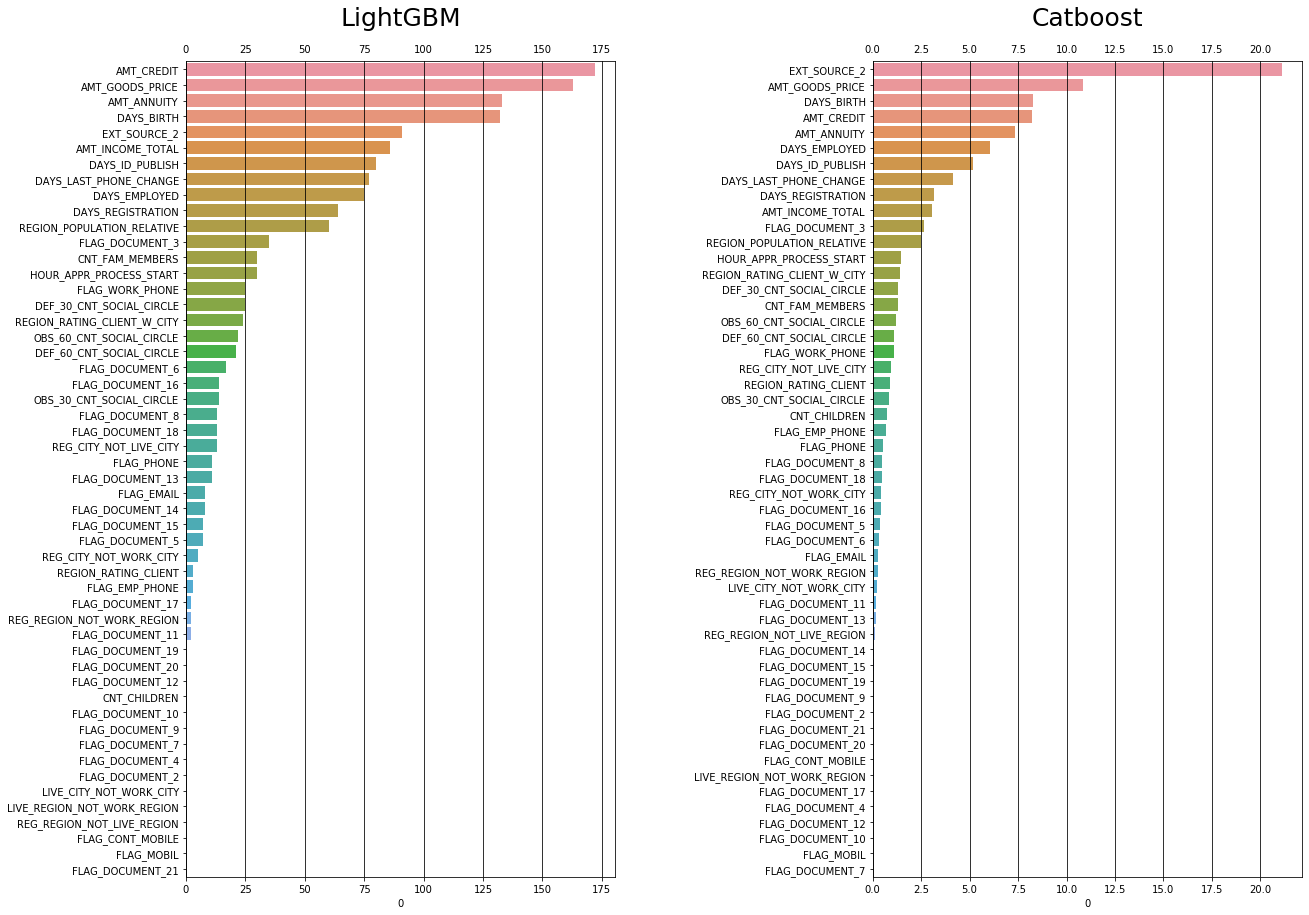

In [323]:
fig, ax = plt.subplots(1, 2)
plt.subplots_adjust(wspace = 0.6)
fig.set_size_inches(20, 15)

sns.barplot(data = feat1, y = 'index', x = 0, ax = ax[0])
ax[0].set_title('LightGBM', pad = 19, fontsize = 25)
ax[0].tick_params(labeltop = True)
ax[0].grid(axis = 'x', color = 'black')
ax[0].set_ylabel('')

sns.barplot(data = feat2, y = 'index', x = 0 , ax = ax[1])
ax[1].set_title('Catboost', pad = 19, fontsize = 25)
ax[1].tick_params(labeltop = True)
ax[1].grid(axis = 'x', color = 'black')
ax[1].set_ylabel('')


plt.show()

На графикам хорошо видны пороги, по которым можно делать отсечку. Для `LightGBM` это чуть больше 25, для `Catboost` чуть меньше 2.5

In [324]:
light_num = feat1[feat1.iloc[:, 1] >= 50].iloc[:, 0]
catb_num = feat2[feat2.iloc[:, 1] >= 2.4].iloc[:, 0]

In [325]:
%%time
light = LGBMClassifier()
model_1 = light.fit(X_train[light_num], y_train)

prob_1 = model_1.predict_proba(X_test[light_num])[:, 1]

print(f'PR LightGBM : {pr(y_test, prob_1)}')

PR LightGBM : 0.1891607332817285
Wall time: 988 ms


In [326]:
%%time
catb = CatBoostClassifier(verbose = False)
model_2 = catb.fit(X_train[catb_num], y_train)

prob_2 = model_2.predict_proba(X_test[catb_num])[:, 1]

print(f'PR CatBoost : {pr(y_test, prob_2)}')

PR CatBoost : 0.18849870380912714
Wall time: 27.9 s


По сравнению с базовыми моделями, качество упало примерно на 0.5. Значительность такого падения зависит от контекста, но как по мне это достаточно много.

### Бонус

__Задание 7. (2.5 балла)__

Вместо One-Hot-Encoding трансформации категориальных переменных воспользуйтесь Mean-Target Encoding со сглаживанием. Вновь подберите оптимальные значения гиперпараметров для комбинации вещественных переменных и категориальных переменных, обработанных с помощью Mean-Target-Encoding. При полученных оптимальных значениях гиперпараметров, как меняется время, необходимое для обучения моделей по сравнению с One-Hot-Encoding? Сравните полученные результаты со встроенными методами обработки категриальных признаков.

In [199]:
from category_encoders.target_encoder import TargetEncoder

In [210]:
te = TargetEncoder(handle_missing = 'value', handle_unknown = 'value', smoothing = 0.1)

te_train = te.fit_transform(X_train[cat], y_train)
te_test = te.transform(X_test[cat], y_test)

X_train_all_1 = pd.concat([X_train[num], te_train], axis = 1)
X_test_all_1 = pd.concat([X_test[num], te_test], axis = 1)

In [211]:
%%time
light = LGBMClassifier()

grid = GridSearchCV(light, param_grid = param_dist, cv = 5, n_jobs = -1, scoring = 'average_precision' )
grid.fit(X_train_all_1, y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Wall time: 4min 12s


In [212]:
%%time
catb = CatBoostClassifier(verbose = False)

grid = GridSearchCV(catb, param_grid = param_dist, cv = 5, n_jobs = -1, scoring = 'average_precision' )
grid.fit(X_train_all_1, y_train)
print(f'The best set of parameters: {grid.best_params_}')

The best set of parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
Wall time: 21min 57s


На 20 секунд быстрее в случае `LGBMClassifier` и на 2 минуты быстрее в случае `CatBoost`. В общем, быстрее, но не на порядок. 

In [329]:
%%time
light = LGBMClassifier(learning_rate = 0.1, max_depth = 2, n_estimators = 500)

model_1 = light.fit(X_train_all_1, y_train)

prob_1 = model_1.predict_proba(X_test_all_1)[:, 1]

print(f'PR LightGBM : {pr(y_test, prob_1)}')

PR LightGBM : 0.20735786742889878
Wall time: 3.27 s


In [330]:
%%time
catb = CatBoostClassifier(learning_rate = 0.05, max_depth = 6, n_estimators = 500, verbose = False)

model_2 = catb.fit(X_train_all_1, y_train)

prob_2 = model_2.predict_proba(X_test_all_1)[:, 1]

print(f'PR CatBoost : {pr(y_test, prob_2)}')

PR CatBoost : 0.2075161324598484
Wall time: 15.7 s


Обучение встроенными методами:

In [262]:
X_train_lgbm, X_test_lgbm = X_train.copy(), X_test.copy()

for c in cat:
    X_train_lgbm[c] = pd.Series(X_train_lgbm[c], dtype = "category")
    X_test_lgbm[c] = pd.Series(X_test_lgbm[c], dtype = "category")

In [265]:
%%time
light = LGBMClassifier(categorical_feature = list(cat), 
                       learning_rate = 0.1, max_depth = 2, n_estimators = 500)

model_1 = light.fit(X_train_lgbm, y_train)

prob_1 = model_1.predict_proba(X_test_lgbm)[:, 1]

print(f'PR LightGBM : {pr(y_test, prob_1)}')

PR LightGBM : 0.20655267380138914
Wall time: 3.33 s


In [253]:
%%time
catb = CatBoostClassifier(cat_features = cat, learning_rate = 0.05, max_depth = 6, n_estimators = 500, verbose = False)

model_2 = catb.fit(X_train, y_train)

prob_2 = model_2.predict_proba(X_test)[:, 1]

print(f'PR CatBoost : {pr(y_test, prob_2)}')

PR CatBoost : 0.2083545077229368
Wall time: 1min 14s


`LGBMClassifier` справился примерно также, `CatBoostClassifier` гораздо медленнее